This is a simple first pass at understanding how to work with openmc.  We'll try and reproduce the pin-cell (example)[https://nbviewer.org/github/openmc-dev/openmc-notebooks/blob/main/pincell.ipynb] 

The goal is to see how to work with the code in a simple example, and figure out the best way to bridge theory with example

This should be a model of a reflective pin-cell, which is the equivalent to modeling an infinite array of fuel pins. 

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import openmc

In [2]:
# Running openmc as is will usually crash when you call the plot() method.  This is because OPENMC_CROSS_SECTIONS is not set in the notebook environment
import os       
os.environ['OPENMC_CROSS_SECTIONS'] = os.path.expanduser(
    '~/openmc-data/endfb-viii.0-hdf5/cross_sections.xml'
)

In [3]:
print(os.getcwd())

/Users/danielokeeffe/Documents/src_dan/learning_openmc/src/examples


In [4]:
# We also need to define the path to the openmc executable
os.environ['PATH'] = os.path.expanduser('~/openmc-source/build/bin') + ':' + os.environ['PATH'] 

Apparently we can generate materials with the Material class. Materials are defined as a set of nuclides with specified atom/weight fractions.  We define objects by unique ids, which are typically just a positive integer. We can also provide a name to make it easier to identify what the id is referring to

In [5]:
uo2 = openmc.Material(1, "uo2")

In [6]:
print(uo2)

Material
	ID             =	1
	Name           =	uo2
	Temperature    =	None
	Density        =	None [sum]
	Volume         =	None [cm^3]
	Depletable     =	False
	S(a,b) Tables  
	Nuclides       



In [7]:
mat = openmc.Material()

In [8]:
print(mat)

Material
	ID             =	2
	Name           =	
	Temperature    =	None
	Density        =	None [sum]
	Volume         =	None [cm^3]
	Depletable     =	False
	S(a,b) Tables  
	Nuclides       



In [9]:
help(uo2.add_nuclide)

Help on method add_nuclide in module openmc.material:

add_nuclide(nuclide: 'str', percent: 'float', percent_type: 'str' = 'ao') method of openmc.material.Material instance
    Add a nuclide to the material

    Parameters
    ----------
    nuclide : str
        Nuclide to add, e.g., 'Mo95'
    percent : float
        Atom or weight percent
    percent_type : {'ao', 'wo'}
        'ao' for atom percent and 'wo' for weight percent



In [10]:
# Add nuclides to our uo2 material
uo2.add_nuclide('U235', 0.03)
uo2.add_nuclide('U238', 0.97)
uo2.add_nuclide('O16', 2.0)

In [11]:
uo2.set_density('g/cm3', 10.0)

In [12]:
print(uo2)

Material
	ID             =	1
	Name           =	uo2
	Temperature    =	None
	Density        =	10.0 [g/cm3]
	Volume         =	None [cm^3]
	Depletable     =	True
	S(a,b) Tables  
	Nuclides       
	U235           =	0.03         [ao]
	U238           =	0.97         [ao]
	O16            =	2.0          [ao]



In [13]:
# We can add materials for the cladding and the coolant
zirconium = openmc.Material(name="zirconium")
zirconium.add_element("Zr", 1.0)
zirconium.set_density('g/cm3', 6.6)

water = openmc.Material(name='h20')
water.add_nuclide('H1', 2.0)
water.add_nuclide('O16', 1.0)
water.set_density('g/cm3', 1.0)

In [14]:
# So the water material we just created will only use free-atom cross sections.  We need to update this so that the bound atom cross section is used at thermal energies.  
water.add_s_alpha_beta('c_H_in_H2O')

In [15]:
# So it looks like the way this works is that when we try and run the transport solver, the first step is to look for a materials.xml file.  To create this file, we need to first instantiate a 
# Materials collection and export it to XML
materials = openmc.Materials([uo2, zirconium, water])

In [16]:
# We can append stuff to the materials class. It actually a subclass of a list
isinstance(materials, list)

True

In [17]:
materials.export_to_xml('../../../openmc_data/pincell_example')

In [18]:
!cat ../../../openmc_data/pincell_example/materials.xml

<?xml version='1.0' encoding='utf-8'?>
<materials>
  <material id="1" name="uo2" depletable="true">
    <density value="10.0" units="g/cm3"/>
    <nuclide name="U235" ao="0.03"/>
    <nuclide name="U238" ao="0.97"/>
    <nuclide name="O16" ao="2.0"/>
  </material>
  <material id="3" name="zirconium">
    <density value="6.6" units="g/cm3"/>
    <nuclide name="Zr90" ao="0.5145"/>
    <nuclide name="Zr91" ao="0.1122"/>
    <nuclide name="Zr92" ao="0.1715"/>
    <nuclide name="Zr94" ao="0.1738"/>
    <nuclide name="Zr96" ao="0.028"/>
  </material>
  <material id="4" name="h20">
    <density value="1.0" units="g/cm3"/>
    <nuclide name="H1" ao="2.0"/>
    <nuclide name="O16" ao="1.0"/>
    <sab name="c_H_in_H2O"/>
  </material>
</materials>


In [19]:
water.remove_nuclide('O16')
water.add_element('O', 1.0)
materials.export_to_xml('../../../openmc_data/pincell_example')

In [20]:
!cat ../../../openmc_data/pincell_example/materials.xml

<?xml version='1.0' encoding='utf-8'?>
<materials>
  <material id="1" name="uo2" depletable="true">
    <density value="10.0" units="g/cm3"/>
    <nuclide name="U235" ao="0.03"/>
    <nuclide name="U238" ao="0.97"/>
    <nuclide name="O16" ao="2.0"/>
  </material>
  <material id="3" name="zirconium">
    <density value="6.6" units="g/cm3"/>
    <nuclide name="Zr90" ao="0.5145"/>
    <nuclide name="Zr91" ao="0.1122"/>
    <nuclide name="Zr92" ao="0.1715"/>
    <nuclide name="Zr94" ao="0.1738"/>
    <nuclide name="Zr96" ao="0.028"/>
  </material>
  <material id="4" name="h20">
    <density value="1.0" units="g/cm3"/>
    <nuclide name="H1" ao="2.0"/>
    <nuclide name="O16" ao="0.9976206"/>
    <nuclide name="O17" ao="0.000379"/>
    <nuclide name="O18" ao="0.0020004"/>
    <sab name="c_H_in_H2O"/>
  </material>
</materials>


In [21]:
# !cat $OPENMC_CROSS_SECTIONS | head -n 10
# print('    ...')
# !cat $OPENMC_CROSS_SECTIONS | tail -n 10

In [22]:
# There's an additional method in add_element we can use called enrichment. For example, if we want to create a 3% enriched U02, we could do:
uo2_three = openmc.Material()
uo2_three.add_element('U', 1.0, enrichment=3.0)
uo2_three.add_element('O', 2.0)
uo2_three.set_density('g/cc', 10.0)

In [23]:
# We can create materials by mixing existing ones.  For example, MOX fuel out of UO2 (97 wt%) and PuO2 (3 wt%):
puo2 = openmc.Material()
puo2.add_nuclide('Pu239', 0.94)
puo2.add_nuclide('Pu240', 0.06)
puo2.add_nuclide('O16', 2.0)
puo2.set_density('g/cm3', 11.5)
mox = openmc.Material.mix_materials([uo2, puo2], [0.97, 0.03], 'wo') # wo here indicates weight fractions. 

In [24]:
sphere = openmc.Sphere(r=1.0)

In [25]:
inside_sphere = -sphere
outside_sphere = +sphere

In [26]:
print((0,0,0) in inside_sphere, (0,0,2) in inside_sphere)
print((0,0,0) in outside_sphere, (0,0,2) in outside_sphere)

True False
False True


In [27]:
# We can construct more complex volumes by combining half-spaces using Boolean operators. For example, the top part of the sphere (i.e. all points inside the sphere that have z > 0)
z_plane = openmc.ZPlane(0)
northern_hemisphere = -sphere & +z_plane

In [28]:
northern_hemisphere.bounding_box

BoundingBox(lower_left=(-1.0, -1.0, 0.0), upper_right=(1.0, 1.0, 1.0))

In [29]:
cell = openmc.Cell()
cell.region = northern_hemisphere

In [30]:
cell.fill = water

In [31]:
# A collection of cells is known as a universe and can be used as a repeatable unit when creating a model. The benefit of creating a universe is that we can visualize our geometry while we're creating it
universe = openmc.Universe()
universe.add_cell(cell)

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

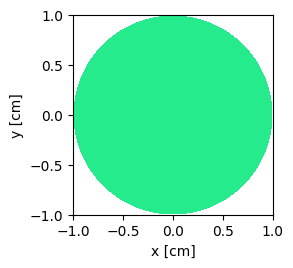

In [32]:
universe.plot(width=(2.0, 2.0), origin=(0.0, 0.0, 0.1))

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

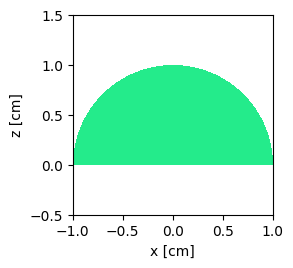

In [33]:
# By default, this plots in the x-y plane. We can change this with the basis argument 
universe.plot(width=(2.0, 2.0), basis='xz')

<Axes: xlabel='x [cm]', ylabel='z [cm]'>

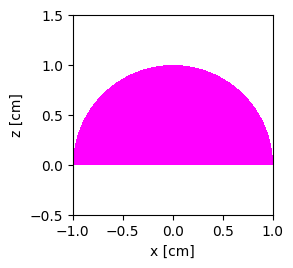

In [34]:
universe.plot(width=(2.0, 2.0), basis='xz', colors={cell: 'fuchsia'})

### Pin cell geometry

Now we can create a pin-cell.  We need three surfaces to define the fuel and clad:

1. The outer surface of the fuel -- a cylinder parallel to the z axis

2. The inner surface of the clad -- same as the above

3. The outer surface of the clad -- same as above

In [35]:
fuel_outer_radius = openmc.ZCylinder(r=0.39)
clad_inner_radius = openmc.ZCylinder(r=0.40)
clad_outer_radius = openmc.ZCylinder(r=0.46)

In [36]:
fuel_region = -fuel_outer_radius
gap_region = +fuel_outer_radius & -clad_inner_radius
clad_region = +clad_inner_radius & -clad_outer_radius

In [37]:
fuel = openmc.Cell(name='fuel')
fuel.fill = uo2
fuel.region = fuel_region 

gap = openmc.Cell(name='air gap')
gap.region = gap_region 

clad = openmc.Cell(name='clad')
clad.fill = zirconium
clad.region = clad_region

In [38]:
# We also need to handle coolant outside of our fuel pin. To do this, we create x and y planes that bound the geometry
pitch = 1.26
left = openmc.XPlane(-pitch/2, boundary_type='reflective')
right = openmc.XPlane(pitch/2, boundary_type='reflective')
bottom = openmc.YPlane(-pitch/2, boundary_type='reflective')
top = openmc.YPlane(pitch/2, boundary_type='reflective')

In [39]:
# The water region is going to be everything outside of the clad outer radius and within the box formed as the intersection of four half-spaces
water_region = +left & -right & +bottom & -top & +clad_outer_radius 

moderator = openmc.Cell(name='moderator')
moderator.fill = water 
moderator.region = water_region

In [40]:
# we could directly define the water region with a RectangularPrism, which returns an Intersection region 
box = openmc.model.RectangularPrism(width=pitch, height=pitch, boundary_type='reflective')

In [41]:
type(box)

openmc.model.surface_composite.RectangularPrism

In [42]:
water_region = -box & +clad_outer_radius 

In [43]:
# The final step is to assign the cells we created to a universe and tell OpenMC that this universe if the root universe in our geometry. The Geometry is the final object that is actually exported to xml
root_universe = openmc.Universe(cells=(fuel, gap, clad, moderator))

geometry = openmc.Geometry()
geometry.root_universe = root_universe 

In [44]:
geometry.export_to_xml('../../../openmc_data/pincell_example/geometry.xml')

In [45]:
!cat ../../../openmc_data/pincell_example/geometry.xml

<?xml version='1.0' encoding='UTF-8'?>
<geometry>
  <cell id="2" name="fuel" material="1" region="-3" universe="2"/>
  <cell id="3" name="air gap" material="void" region="3 -4" universe="2"/>
  <cell id="4" name="clad" material="3" region="4 -5" universe="2"/>
  <cell id="5" name="moderator" material="4" region="6 -7 8 -9 5" universe="2"/>
  <surface id="3" type="z-cylinder" coeffs="0.0 0.0 0.39"/>
  <surface id="4" type="z-cylinder" coeffs="0.0 0.0 0.4"/>
  <surface id="5" type="z-cylinder" coeffs="0.0 0.0 0.46"/>
  <surface id="6" type="x-plane" boundary="reflective" coeffs="-0.63"/>
  <surface id="7" type="x-plane" boundary="reflective" coeffs="0.63"/>
  <surface id="8" type="y-plane" boundary="reflective" coeffs="-0.63"/>
  <surface id="9" type="y-plane" boundary="reflective" coeffs="0.63"/>
</geometry>


In [46]:
# Create a point source
point = openmc.stats.Point((0, 0, 0))
source = openmc.IndependentSource(space=point)

In [47]:
# Now we can create a Settings object. We give it the source we created, along with specifying how many batches and particles we want to run
settings = openmc.Settings()
settings.source = source
settings.batches = 100
settings.inactive = 10
settings.particles = 1000

In [48]:
settings.export_to_xml('../../../openmc_data/pincell_example')

In [49]:
!cat ../../../openmc_data/pincell_example/settings.xml

<?xml version='1.0' encoding='UTF-8'?>
<settings>
  <run_mode>eigenvalue</run_mode>
  <particles>1000</particles>
  <batches>100</batches>
  <inactive>10</inactive>
  <source type="independent" strength="1.0" particle="neutron">
    <space type="point">
      <parameters>0 0 0</parameters>
    </space>
  </source>
</settings>


In [50]:
# We can set up our own tallies as well.  We could tally the total, fission, absorption, and (n, gamma) reaction rates for U235 in the cell containing fuel.  
# Filters allow us to specify where in phase-space we want events to be tallied and scores tell us what we want to tally. In this case, the where is "the fuel cell". We will create a cell filter
# specifying the fuel cell
cell_filter = openmc.CellFilter(fuel)
tally = openmc.Tally(1)
tally.filters = [cell_filter]

In [55]:
# Then we tell it what to tally. This is the total, fission, absorption, and (n, gamma) reaction rates in U235
tally.nuclides = ['U235']
tally.scores = ['total', 'fission', 'absorption', '(n,gamma)']

In [56]:
tallies = openmc.Tallies([tally])
tallies.export_to_xml('../../../openmc_data/pincell_example')

In [57]:
!cat ../../../openmc_data/pincell_example/tallies.xml

<?xml version='1.0' encoding='UTF-8'?>
<tallies>
  <filter id="1" type="cell">
    <bins>2</bins>
  </filter>
  <tally id="1">
    <filters>1</filters>
    <nuclides>U235</nuclides>
    <scores>total fission absorption (n,gamma)</scores>
  </tally>
</tallies>


In [58]:
openmc.run(path_input='../../../openmc_data/pincell_example', output=True)

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [59]:
!cat tallies.out

 ============================>     TALLY 1     <============================

 Cell 2
   U235
     Total Reaction Rate                  0.734297 +/- 0.0027381
     Fission Rate                         0.550799 +/- 0.00224093
     Absorption Rate                      0.662248 +/- 0.00263924
     (n,gamma)                            0.111449 +/- 0.000412508


In [60]:
plot = openmc.Plot()
plot.filename = 'pinplot'
plot.width = (pitch, pitch)
plot.pixels = (200, 200)
plot.color_by = 'material'
plot.colors = {uo2: 'yellow', water: 'blue'}

/Users/danielokeeffe/Documents/src_dan/learning_openmc/.venv/lib/python3.13/site-packages/openmc/plots.py:1387: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(


In [61]:
plots = openmc.Plots([plot])
plots.export_to_xml('../../../openmc_data/pincell_example')

In [62]:
openmc.plot_geometry(path_input='../../../openmc_data/pincell_example')

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

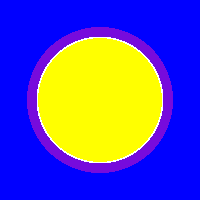

In [63]:
from IPython.display import Image
Image("pinplot.png")

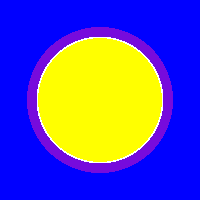

In [65]:
plot.to_ipython_image(cwd='../../../openmc_data/pincell_example')